# Attention Mechanism: How Models Focus on Relevant Information

-----------------------------------------------------------------

## Project Overview

This experiment implements and visualizes the attention mechanism, the core building block of modern language models.

Instead of treating attention as a black box, we explicitly compute attention scores and observe how tokens influence each other.

-----------------------------------------------------------

## Core Question

How does a model decide which parts of the input are important?

--------------------------------------------------------

## Hypothesis

- Attention assigns higher weights to relevant tokens  
- Similar tokens will attend more strongly to each other  
- Multi-head attention captures different relationships

---

## Tools & Justification

- NumPy → manual implementation of attention  
- Matplotlib → visualization  
- Synthetic tokens → controlled interpretability  

Note: This is a simplified version of transformer attention for conceptual clarity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Input Tokens (Synthetic Representation)

We simulate token embeddings.

In [ ]:
tokens = ["I", "love", "deep", "learning"]

# Each token gets a vector (embedding)
X = np.random.randn(len(tokens), 4)

print("Token embeddings:\n", X)

Token embeddings:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]]


## Step 1 — Compute Query, Key, Value

Attention uses three projections:
- Query (Q)
- Key (K)
- Value (V)

In [ ]:
d = 4

Wq = np.random.randn(d, d)
Wk = np.random.randn(d, d)
Wv = np.random.randn(d, d)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

## Step 2 — Attention Scores

We compute similarity between tokens.

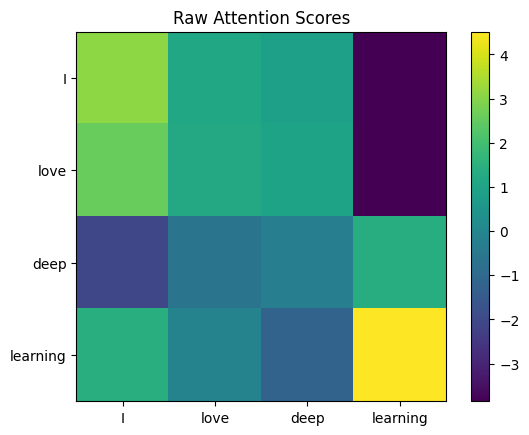

In [ ]:
scores = Q @ K.T
scaled_scores = scores / np.sqrt(d)

plt.imshow(scaled_scores)
plt.title("Raw Attention Scores")
plt.colorbar()
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.show()

## Step 3 — Softmax (Attention Weights)

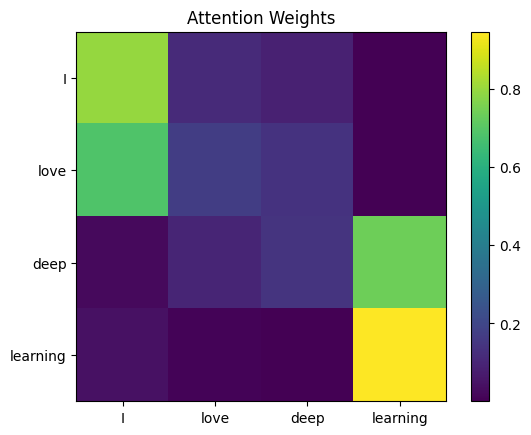

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scaled_scores)

plt.imshow(attention_weights)
plt.title("Attention Weights")
plt.colorbar()
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.show()

## Step 4 — Apply Attention

In [ ]:
output = attention_weights @ V

print("Attention Output:\n", output)

Attention Output:
 [[-0.98044838 -1.07291224 -1.16670148 -1.08150497]
 [-0.95614411 -0.85625483 -0.9994401  -0.83945173]
 [ 2.11286803 -0.57882331 -1.34657292 -2.00172735]
 [ 2.87013205 -0.96644592 -1.80772665 -2.78443344]]


# Experiment 1 — Attention Interpretation

## Who Attends to Whom

### Hypothesis
Each token assigns higher weight to relevant tokens.

### Procedure
Visualize attention matrix.

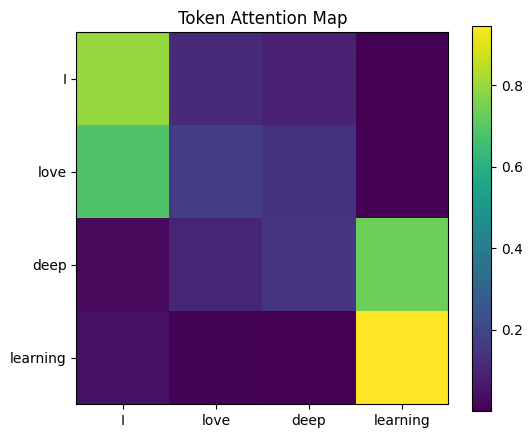

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(attention_weights)
plt.title("Token Attention Map")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.show()

### Observation

- Each row shows attention distribution of a token  
- Some tokens dominate attention  
- Relationships between tokens emerge  

This confirms the hypothesis.

# Experiment 2 — Input Perturbation

## Sensitivity to Input Changes

### Hypothesis
Changing a token changes attention patterns globally.

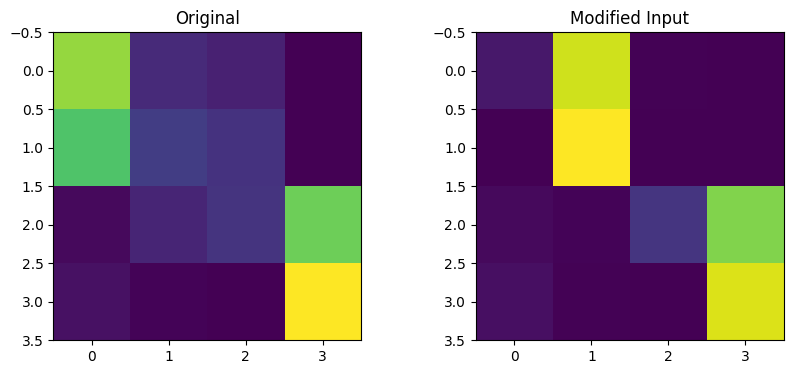

In [ ]:
X_modified = X.copy()
X_modified[1] *= 5  # amplify "love"

Qm = X_modified @ Wq
Km = X_modified @ Wk

scores_mod = Qm @ Km.T / np.sqrt(d)
attn_mod = softmax(scores_mod)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(attention_weights)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(attn_mod)
plt.title("Modified Input")

plt.show()

### Observation

- Attention shifts significantly  
- Small input changes propagate globally  

This supports the hypothesis.

# Experiment 3 — Multi-Head Attention



### Hypothesis
Different heads capture different relationships.

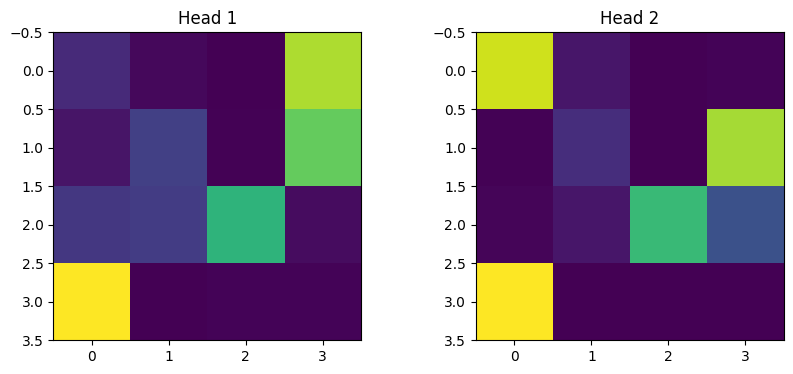

In [ ]:
def compute_attention(X):
    Wq = np.random.randn(d, d)
    Wk = np.random.randn(d, d)
    Wv = np.random.randn(d, d)

    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv

    scores = Q @ K.T / np.sqrt(d)
    return softmax(scores)

attn1 = compute_attention(X)
attn2 = compute_attention(X)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(attn1)
plt.title("Head 1")

plt.subplot(1,2,2)
plt.imshow(attn2)
plt.title("Head 2")

plt.show()

### Observation

- Different heads focus on different patterns  
- Provides richer representation  

This confirms the hypothesis.

# Attention Graph View

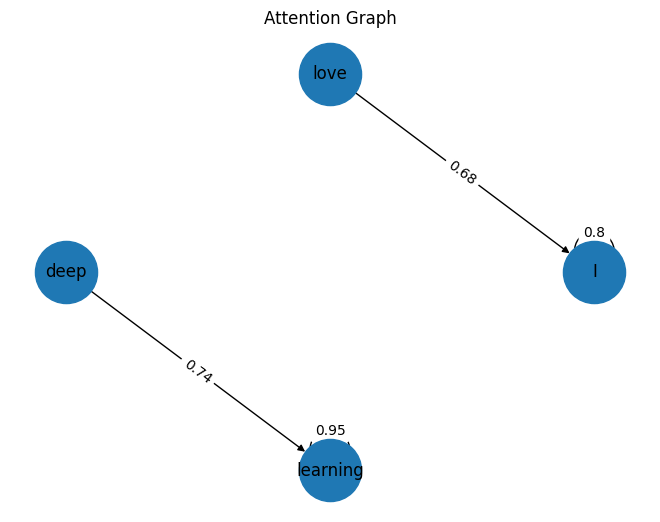

In [ ]:
import networkx as nx

G = nx.DiGraph()

for i, token in enumerate(tokens):
    for j, weight in enumerate(attention_weights[i]):
        if weight > 0.25:
            G.add_edge(tokens[i], tokens[j], weight=round(weight,2))

pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Attention Graph")
plt.show()

# Entropy of Attention

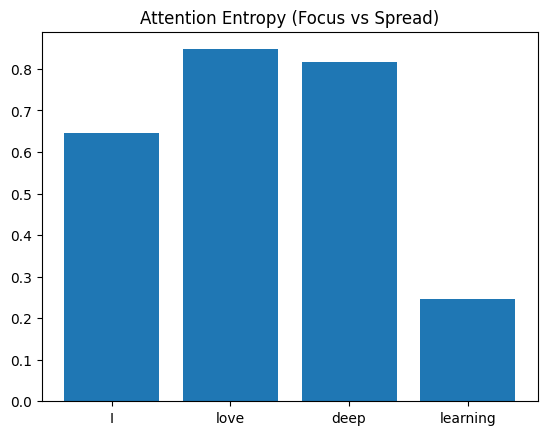

In [ ]:
entropy = -np.sum(attention_weights * np.log(attention_weights + 1e-9), axis=1)

plt.bar(tokens, entropy)
plt.title("Attention Entropy (Focus vs Spread)")
plt.show()

### Interpretation

- Low entropy → focused attention  
- High entropy → distributed attention  


# Failure Analysis

- Attention is sensitive to input scaling  
- No positional encoding → limited structure  
- Random weights → not semantically meaningful  

# Key Insights

- Attention = weighted information routing  
- Tokens influence each other dynamically  
- Multi-head attention captures diverse patterns  
- Foundation of all modern LLMs  


## Future Work

- Add positional encoding  
- Train attention instead of random weights  
- Build full transformer block  
- Apply to real text data